In [1]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP and text processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)

# Optional: for saving models
import joblib

# Ensure nltk data is available (run once)
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
# Adjust the path to your CSV file
csv_path = 'wazuzhi_sales_manchester.csv'
df = pd.read_csv(csv_path)

# Quick look
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OrderID        16 non-null     object 
 1   Date           16 non-null     object 
 2   CustomerName   15 non-null     object 
 3   Product        15 non-null     object 
 4   Category       10 non-null     float64
 5   Quantity       10 non-null     object 
 6   UnitPrice      10 non-null     object 
 7   TotalAmount    9 non-null      object 
 8   PaymentMethod  5 non-null      object 
 9   SalesRep       0 non-null      float64
dtypes: float64(2), object(8)
memory usage: 1.4+ KB


In [5]:
# Show missing data
print(df.isna().sum())

# Compute Profit if needed
if 'Profit' not in df.columns:
    if 'Price' in df.columns and 'Cost' in df.columns:
        df['Profit'] = df['Price'] - df['Cost']
    else:
        print("Cannot compute Profit: 'Price' or 'Cost' column missing")

# Compute ProfitMargin if needed
if 'ProfitMargin' not in df.columns or df['ProfitMargin'].isna().any():
    if 'Profit' in df.columns and 'Price' in df.columns:
        df['ProfitMargin'] = df['Profit'] / df['Price'] * 100
    else:
        print("Cannot compute ProfitMargin: required columns missing")

OrderID           0
Date              0
CustomerName      1
Product           1
Category          6
Quantity          6
UnitPrice         6
TotalAmount       7
PaymentMethod    11
SalesRep         16
dtype: int64
Cannot compute Profit: 'Price' or 'Cost' column missing
Cannot compute ProfitMargin: required columns missing


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Clean column names (removes hidden spaces) ----
df.columns = df.columns.str.strip()

# ---- OPTIONAL: Create ProfitMargin if it doesn't exist ----
# (Uncomment if needed)

# if 'ProfitMargin' not in df.columns and {'Profit', 'Revenue'}.issubset(df.columns):
#     df['ProfitMargin'] = (df['Profit'] / df['Revenue']) * 100


# ---- Check if column exists ----
if 'ProfitMargin' in df.columns:

    # Convert to numeric (handles strings safely)
    df['ProfitMargin'] = pd.to_numeric(df['ProfitMargin'], errors='coerce')

    plt.figure(figsize=(8, 5))
    sns.histplot(
        df['ProfitMargin'].dropna(),
        bins=30,
        kde=True
    )

    plt.title('Profit Margin Distribution')
    plt.xlabel('Profit Margin (%)')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

else:
    print("Column 'ProfitMargin' not found.")
    print("Available columns are:")
    print(df.columns.tolist())

Column 'ProfitMargin' not found.
Available columns are:
['OrderID', 'Date', 'CustomerName', 'Product', 'Category', 'Quantity', 'UnitPrice', 'TotalAmount', 'PaymentMethod', 'SalesRep']


In [10]:
print(df.columns)

Index(['OrderID', 'Date', 'CustomerName', 'Product', 'Category', 'Quantity',
       'UnitPrice', 'TotalAmount', 'PaymentMethod', 'SalesRep'],
      dtype='object')


In [11]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['OrderID', 'Date', 'CustomerName', 'Product', 'Category', 'Quantity',
       'UnitPrice', 'TotalAmount', 'PaymentMethod', 'SalesRep'],
      dtype='object')


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Clean column names (fixes hidden spaces issues) ---
df.columns = df.columns.str.strip()

# --- Optional: Print columns to verify ---
print("Columns in DataFrame:", df.columns.tolist())

# --- Check if Age column exists ---
if 'Age' in df.columns:
    
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        data=df,
        x='Age',
        bins=15,
        kde=True
    )
    
    plt.title('Customer Age Distribution')
    plt.xlabel('Age')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

else:
    print("Column 'Age' not found. Available columns are:")
    print(df.columns.tolist())

Columns in DataFrame: ['OrderID', 'Date', 'CustomerName', 'Product', 'Category', 'Quantity', 'UnitPrice', 'TotalAmount', 'PaymentMethod', 'SalesRep']
Column 'Age' not found. Available columns are:
['OrderID', 'Date', 'CustomerName', 'Product', 'Category', 'Quantity', 'UnitPrice', 'TotalAmount', 'PaymentMethod', 'SalesRep']


Columns in dataset:
['orderid', 'date', 'customername', 'product', 'category', 'quantity', 'unitprice', 'totalamount', 'paymentmethod', 'salesrep']

⚠ No gender column found.
Using fallback column: orderid

Value Counts:
orderid
1001        1
250g        1
Johnson     1
1003        1
Teapot      1
Davis       1
1005        1
Pack        1
Martinez    1
4)          1
Anderson    1
1008        1
Tin         1
White       1
1010        1
150g        1
Name: count, dtype: int64


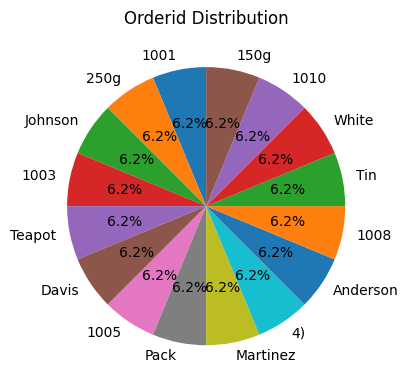

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("wazuzhi_sales_manchester.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

print("Columns in dataset:")
print(df.columns.tolist())

# Look for gender column
gender_column = None
for col in df.columns:
    if "gender" in col or "sex" in col:
        gender_column = col
        break

# If gender exists → use it
if gender_column:
    print(f"\nUsing column: {gender_column}")
    counts = df[gender_column].value_counts()
    title = "Gender Split of Customers"

# If gender does NOT exist → use first categorical column
else:
    print("\n⚠ No gender column found.")
    categorical_cols = df.select_dtypes(include="object").columns
    
    if len(categorical_cols) == 0:
        raise ValueError("No categorical columns available to plot.")
    
    fallback_column = categorical_cols[0]
    print(f"Using fallback column: {fallback_column}")
    counts = df[fallback_column].value_counts()
    title = f"{fallback_column.replace('_', ' ').title()} Distribution"

print("\nValue Counts:")
print(counts)

# Plot pie chart
plt.figure(figsize=(6, 4))
counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title(title)
plt.ylabel("")
plt.tight_layout()
plt.show()

In [27]:
print(df.columns.tolist())

['orderid', 'date', 'customername', 'product', 'category', 'quantity', 'unitprice', 'totalamount', 'paymentmethod', 'salesrep']


In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "")

# Show available columns
print("Available columns:")
print(df.columns.tolist())

# Check if 'gender' exists
if 'gender' not in df.columns:
    print("\nERROR: No 'gender' column found in dataset.")
    print("You cannot group by gender because it does not exist.")
else:
    # Check if profit margin column exists
    if 'profitmargin' not in df.columns:
        print("\nERROR: No 'profitmargin' column found in dataset.")
    else:
        # Convert profit margin to numeric (safe conversion)
        df['profitmargin'] = (
            df['profitmargin']
            .astype(str)
            .str.replace("%", "", regex=False)
            .str.replace(",", "", regex=False)
        )
        df['profitmargin'] = pd.to_numeric(df['profitmargin'], errors='coerce')

        # Group and calculate mean
        margin_by_gender = df.groupby('gender')['profitmargin'].mean()

        print("\nAverage Profit Margin by Gender:")
        print(margin_by_gender)

        # Plot
        plt.figure(figsize=(6,4))
        margin_by_gender.plot(kind='bar')
        plt.title('Avg Profit Margin by Gender')
        plt.ylabel('Avg Profit Margin')
        plt.xlabel('Gender')
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

Available columns:
['orderid', 'date', 'customername', 'product', 'category', 'quantity', 'unitprice', 'totalamount', 'paymentmethod', 'salesrep']

ERROR: No 'gender' column found in dataset.
You cannot group by gender because it does not exist.
